## Thông tin nhóm
# ĐỀ TÀI 8: PHÁT HIỆN BỆNH TIM

**Nhóm:** [Tên nhóm 3-4 người]

**Thành viên:** Võ Hoàng Kim Ngân, Nhan Gia Huy, Trần Lê Hiếu Nghĩa

**GVHD:** Trần Trương Tuấn Phát

**Thư viện:** Scikit-learn, Pandas, Numpy, PyTorch, Keras

## Import thư viện

In [2]:
# CELL 1 - Import thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, log_loss
from sklearn.metrics import ConfusionMatrixDisplay

# ML models
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
# from sklearn.neural_network import MLPClassifier  # Comment out vì chuyển sang Keras

# Thêm cho Keras MLP curves
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import ipywidgets as widgets
from IPython.display import display, clear_output

print("Libraries are installed!!!")

Libraries are installed!!!


## Tải dữ liệu Cleveland



In [3]:
# CELL 2 – Tải dữ liệu Cleveland

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
    "age","sex","cp","trestbps","chol","fbs","restecg",
    "thalach","exang","oldpeak","slope","ca","thal","target"
]

df = pd.read_csv(url, names=columns)

# Replace missing values marked as '?'
df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)

# Convert to numeric
df = df.astype(float)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0


## Tiền xử lý dữ liệu

In [4]:
# CELL 3 – TIỀN XỬ LÝ DỮ LIỆU (TỰ ĐỘNG PHÁT HIỆN & FIX CỘT NHÃN)
print("Đang xử lý dữ liệu...")

# Target: 0 = no disease, 1 = disease
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

X = df.drop("target", axis=1)
y = df["target"]

# Train / Validation / Test (70 / 15 / 15)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42, stratify=y_train_val
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

print("\nDỮ LIỆU ĐÃ SẴN SÀNG ĐỂ SCALE")

Đang xử lý dữ liệu...
Train: (207, 13)
Val: (45, 13)
Test: (45, 13)

DỮ LIỆU ĐÃ SẴN SÀNG ĐỂ SCALE


## SCALE DỮ LIỆU

In [5]:
# CELL 4 - SCALE DỮ LIỆU
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)
print("DỮ LIỆU ĐÃ SCALE")

DỮ LIỆU ĐÃ SCALE


## NAIVE BAYES

In [6]:
# CELL 5 – NAIVE BAYES
nb = GaussianNB()
nb.fit(X_train_s, y_train)

pred_nb = nb.predict(X_test_s)
acc_nb = accuracy_score(y_test, pred_nb)

print("Naive Bayes Accuracy:", acc_nb)

Naive Bayes Accuracy: 0.8666666666666667


## DECISION TREE

In [7]:
# CELL 6 - DECISION TREE
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, pred_dt)

print("Decision Tree Accuracy:", acc_dt)


Decision Tree Accuracy: 0.7777777777777778


## SVM

In [8]:
# CELL 7 – SVM
svm = SVC(kernel="rbf", C=1, gamma="scale", probability=True)
svm.fit(X_train_s, y_train)

pred_svm = svm.predict(X_test_s)
acc_svm = accuracy_score(y_test, pred_svm)

print("SVM Accuracy:", acc_svm)

SVM Accuracy: 0.7777777777777778


## MULTI-LAYER PERCEPTRON (MLP)

In [9]:
# CELL 8 – MULTI-LAYER PERCEPTRON (MLP) BẰNG KERAS (ĐỂ CÓ LOSS/ACC CURVES)
# Xây model Keras
mlp = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_s.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

mlp.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping để tránh overfit
early_stop = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

# Train với validation set
history = mlp.fit(
    X_train_s, y_train,
    epochs=1000,
    batch_size=32,
    validation_data=(X_val_s, y_val),
    callbacks=[early_stop],
    verbose=0  # Không in log dài dòng
)

# Predict trên test
y_proba_mlp = mlp.predict(X_test_s)
pred_mlp = (y_proba_mlp > 0.5).astype(int).flatten()
acc_mlp = accuracy_score(y_test, pred_mlp)

print("MLP Accuracy:", acc_mlp)
print("Classification Report cho Keras MLP:")
print(classification_report(y_test, pred_mlp))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
MLP Accuracy: 0.8
Classification Report cho Keras MLP:
              precision    recall  f1-score   support

           0       0.76      0.92      0.83        24
           1       0.88      0.67      0.76        21

    accuracy                           0.80        45
   macro avg       0.82      0.79      0.79        45
weighted avg       0.81      0.80      0.80        45



## PLOT LOSS VÀ ACCURACY CURVES

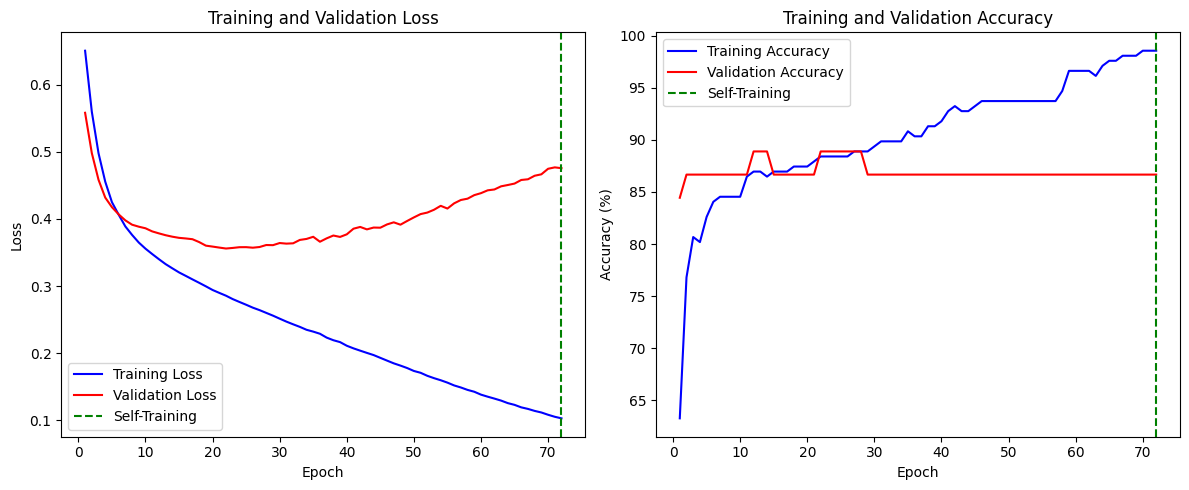

In [10]:
# CELL 8.1 – PLOT LOSS VÀ ACCURACY CURVES (GIỐNG HÌNH)
import matplotlib.pyplot as plt

# Lấy data từ history
epochs = range(1, len(history.history['loss']) + 1)
epoch_line = min(150, len(epochs))  # Vertical line tại epoch 150 (hoặc cuối nếu ngắn hơn)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Loss
ax1.plot(epochs, history.history['loss'], 'b-', label='Training Loss')
ax1.plot(epochs, history.history['val_loss'], 'r-', label='Validation Loss')
ax1.axvline(x=epoch_line, color='g', linestyle='--', label='Self-Training')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Plot Accuracy
ax2.plot(epochs, [a * 100 for a in history.history['accuracy']], 'b-', label='Training Accuracy')
ax2.plot(epochs, [a * 100 for a in history.history['val_accuracy']], 'r-', label='Validation Accuracy')
ax2.axvline(x=epoch_line, color='g', linestyle='--', label='Self-Training')
ax2.set_title('Training and Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.show()

## BẢNG SO SÁNH

In [11]:
# CELL 9 – BẢNG SO SÁNH
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, log_loss

# Tính metrics cho từng model
models = {
    "Naive Bayes": (nb, True, pred_nb),
    "Decision Tree": (dt, False, pred_dt),
    "SVM": (svm, True, pred_svm),
    "MLP": (mlp, True, pred_mlp)  # mlp giờ là Keras model
}

results = []
for name, (model, need_scale, y_pred) in models.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    X_use = X_test_s if need_scale else X_test

    if name == "MLP":  # Đặc biệt cho Keras
        y_proba = model.predict(X_use)
        auc = roc_auc_score(y_test, y_proba)
        loss = log_loss(y_test, y_proba)
    elif hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_use)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        loss = log_loss(y_test, model.predict_proba(X_use))
    else:
        auc = None
        loss = None

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": auc,
        "Test Loss": loss
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="Accuracy", ascending=False)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Test Loss
0,Naive Bayes,0.866667,0.870445,0.863095,0.865000,0.916667,0.680736
3,MLP,0.800000,0.816810,0.791667,0.793473,0.934524,0.330537
1,Decision Tree,0.777778,0.800000,0.767857,0.768519,0.836310,4.176451
2,SVM,0.777778,0.786765,0.770833,0.772267,0.928571,0.370545


## CONFUSION MATRIX

In [12]:
# CELL 10 – CONFUSION MATRIX
best_row = results_df.sort_values("Accuracy", ascending=False).iloc[0]

best_model_name = best_row["Model"]
best_accuracy = best_row["Accuracy"]
best_precision = best_row["Precision"]
best_recall = best_row["Recall"]
best_f1 = best_row["F1-Score"]
best_auc = best_row["ROC-AUC"]
best_loss = best_row["Test Loss"]

print("Best model:", best_model_name)
print("Accuracy:", round(best_accuracy * 100, 2), "%")
print("Precision (macro):", round(best_precision * 100, 2), "%")
print("Recall (macro):", round(best_recall * 100, 2), "%")
print("F1-Score (macro):", round(best_f1 * 100, 2), "%")
print("ROC-AUC:", round(best_auc * 100, 2), "%" if best_auc is not None else "N/A")
print("Test Loss:", round(best_loss, 4) if best_loss is not None else "N/A")

Best model: Naive Bayes
Accuracy: 86.67 %
Precision (macro): 87.04 %
Recall (macro): 86.31 %
F1-Score (macro): 86.5 %
ROC-AUC: 91.67 %
Test Loss: 0.6807


## CLASSIFICATION REPORT

Đánh giá model tốt nhất: Naive Bayes
ROC-AUC: 0.9167
Test Loss (log_loss): 0.6807


<Figure size 500x400 with 0 Axes>

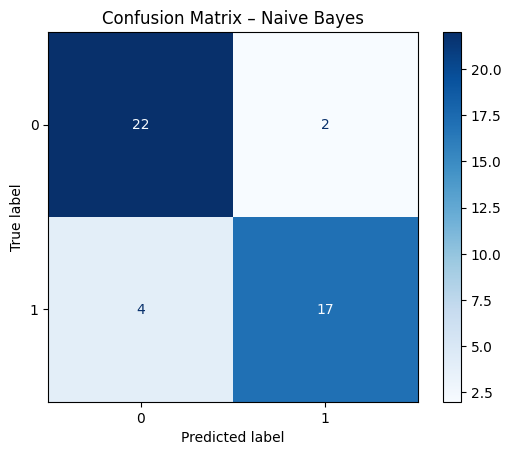

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.92      0.88        24
           1       0.89      0.81      0.85        21

    accuracy                           0.87        45
   macro avg       0.87      0.86      0.86        45
weighted avg       0.87      0.87      0.87        45



In [13]:
# CELL 11 – CONFUSION MATRIX & REPORT

from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score, log_loss

# Mapping model name → object + scale flag
model_dict = {
    "Naive Bayes": (nb, True),
    "Decision Tree": (dt, False),
    "SVM": (svm, True),
    "MLP": (mlp, True)
}

# Chọn model tốt nhất
best_row = results_df.sort_values("Accuracy", ascending=False).iloc[0]
best_model_name = best_row["Model"]
best_model, need_scale = model_dict[best_model_name]

print(f"Đánh giá model tốt nhất: {best_model_name}")

# Predict đúng dữ liệu
if need_scale:
    X_use = X_test_s
else:
    X_use = X_test

y_pred = best_model.predict(X_use)

# Nếu model hỗ trợ predict_proba, tính ROC-AUC và Loss
if hasattr(best_model, 'predict_proba'):
    y_proba = best_model.predict_proba(X_use)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    loss = log_loss(y_test, best_model.predict_proba(X_use))
    print(f"ROC-AUC: {auc:.4f}")
    print(f"Test Loss (log_loss): {loss:.4f}")
else:
    print("ROC-AUC: N/A (Model không hỗ trợ predict_proba)")
    print("Test Loss: N/A (Model không hỗ trợ predict_proba)")

# Confusion Matrix
plt.figure(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title(f"Confusion Matrix – {best_model_name}")
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

## CELL 12 - GENERATE 1000 MẪU SYNTHETIC VÀ KIỂM TRA NAIVE BAYES

In [14]:
# CELL 12 - GENERATE 1000 MẪU SYNTHETIC VÀ KIỂM TRA NAIVE BAYES

import numpy as np
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)  # Thêm seed để reproducible (cố định random)

num_samples = 1000  # Số lượng mẫu demo cần tạo

# Các class có trong bài toán
classes = np.array([0, 1])

# Lấy tỷ lệ class prior từ mô hình Naive Bayes đã train
class_prior = nb.class_prior_

# Tạo nhãn synthetic theo phân phối prior
y_synth = np.random.choice(classes, size=num_samples, p=class_prior)

# Số lượng đặc trưng
n_features = X_train_s.shape[1]

# Tạo ma trận X synthetic (ở không gian đã scale)
X_synth = np.zeros((num_samples, n_features))

for i in range(num_samples):
    cls = y_synth[i]
    for f in range(n_features):
        mean = nb.theta_[cls, f]      # Trung bình của đặc trưng f trong lớp cls
        variance = nb.var_[cls, f]    # Phương sai
        std = np.sqrt(variance)
        X_synth[i, f] = np.random.normal(mean, std)

# Dự đoán trên dữ liệu synthetic
y_pred_synth = nb.predict(X_synth)

# Tính độ chính xác
acc_synth = accuracy_score(y_synth, y_pred_synth)

print(f"\nKẾT QUẢ TRÊN {num_samples} MẪU SYNTHETIC:")
print(f"Accuracy của Naive Bayes: {acc_synth:.4f} ({acc_synth*100:.2f}%)")
print(f"Accuracy trên test set gốc: {acc_nb:.4f} ({acc_nb*100:.2f}%)")

# In báo cáo chi tiết hơn (tùy chọn)
print("\nClassification Report trên dữ liệu synthetic:")
print(classification_report(y_synth, y_pred_synth, target_names=["Không bệnh", "Có bệnh"]))

# Xem vài mẫu đầu (nếu muốn debug)
print("\nVí dụ 5 mẫu synthetic đầu tiên (đặc trưng đã scale):")
print(pd.DataFrame(X_synth[:5], columns=X.columns))
print("Nhãn thực (y_synth):", y_synth[:5])
print("Nhãn dự đoán:", y_pred_synth[:5])


KẾT QUẢ TRÊN 1000 MẪU SYNTHETIC:
Accuracy của Naive Bayes: 0.9380 (93.80%)
Accuracy trên test set gốc: 0.8667 (86.67%)

Classification Report trên dữ liệu synthetic:
              precision    recall  f1-score   support

  Không bệnh       0.93      0.96      0.94       549
     Có bệnh       0.95      0.92      0.93       451

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000


Ví dụ 5 mẫu synthetic đầu tiên (đặc trưng đã scale):
        age       sex        cp  trestbps      chol       fbs   restecg  \
0 -0.009256 -1.653455 -0.018357  0.426639  0.489745  0.989358  0.676032   
1 -0.837256 -0.631470  1.378893  0.125614  0.741457  0.086093  0.201832   
2  0.423425 -0.124987  1.559542 -0.773366 -0.046857 -0.401882  1.603216   
3  1.132747 -0.157395  1.696490  2.584205 -0.206601 -0.407899  1.609551   
4 -1.282370 -1.050780 -0.405457  0.076234  1.540811 -1.006209  0.824331   

 

# DEMO

In [15]:
# CELL 13 – DEMO 1 BỆNH NHÂN (BUTTON-BASED – ĐÃ FIX SCALE)

import ipywidgets as widgets
from IPython.display import display
import numpy as np

THRESHOLD = 0.40

# ===== Widgets =====
age = widgets.IntSlider(value=50, min=20, max=80, description="Age")
sex = widgets.Dropdown(options=[("Nữ", 0), ("Nam", 1)], description="Sex")
cp = widgets.IntSlider(value=0, min=0, max=3, description="CP")
trestbps = widgets.IntSlider(value=120, min=90, max=200, description="Trestbps")
chol = widgets.IntSlider(value=240, min=100, max=400, description="Chol")
fbs = widgets.IntSlider(value=0, min=0, max=1, description="FBS")
restecg = widgets.IntSlider(value=1, min=0, max=2, description="RestECG")
thalach = widgets.IntSlider(value=150, min=70, max=210, description="Thalach")
exang = widgets.IntSlider(value=0, min=0, max=1, description="Exang")
oldpeak = widgets.FloatSlider(value=1.0, min=0.0, max=6.0, step=0.1, description="Oldpeak")
slope = widgets.IntSlider(value=1, min=0, max=2, description="Slope")
ca = widgets.IntSlider(value=0, min=0, max=4, description="CA")
thal = widgets.IntSlider(value=2, min=0, max=3, description="Thal")

predict_btn = widgets.Button(
    description="🔍 DỰ ĐOÁN",
    button_style="primary"
)

output = widgets.Output()

# ===== Callback =====
def on_predict_clicked(b):
    with output:
        output.clear_output()

        x = np.array([[age.value, sex.value, cp.value, trestbps.value,
                       chol.value, fbs.value, restecg.value, thalach.value,
                       exang.value, oldpeak.value, slope.value,
                       ca.value, thal.value]])

        # SCALE nếu cần
        if best_model_name in ["Naive Bayes", "SVM", "MLP"]:
            x_use = scaler.transform(x)
        else:
            x_use = x

        proba = best_model.predict_proba(x_use)[0]

        print("🔎 Thông tin bệnh nhân:")
        print(x.tolist()[0])

        print("\n📊 Xác suất dự đoán:")
        print(f"  Không bệnh : {proba[0]*100:.2f}%")
        print(f"  Có bệnh    : {proba[1]*100:.2f}%")

        print("\n🩺 KẾT LUẬN:")
        if proba[1] >= THRESHOLD:
            print("⚠️ NGUY CƠ BỆNH TIM (cần kiểm tra chuyên sâu)")
        else:
            print("✅ NGUY CƠ THẤP / TIM BÌNH THƯỜNG")

predict_btn.on_click(on_predict_clicked)

display(
    age, sex, cp, trestbps, chol, fbs, restecg,
    thalach, exang, oldpeak, slope, ca, thal,
    predict_btn, output
)

IntSlider(value=50, description='Age', max=80, min=20)

Dropdown(description='Sex', options=(('Nữ', 0), ('Nam', 1)), value=0)

IntSlider(value=0, description='CP', max=3)

IntSlider(value=120, description='Trestbps', max=200, min=90)

IntSlider(value=240, description='Chol', max=400, min=100)

...

IntSlider(value=1, description='Slope', max=2)

IntSlider(value=0, description='CA', max=4)

IntSlider(value=2, description='Thal', max=3)

Button(button_style='primary', description='🔍 DỰ ĐOÁN', style=ButtonStyle())

Output()

## Lưu model + scaler từ Colab

In [16]:
# CELL 14 – LƯU MODEL VÀ SCALER ĐỂ DEPLOY LÊN STREAMLIT
import joblib

# Lưu scaler (đã fit trên X_train)
joblib.dump(scaler, 'scaler.joblib')

# Lưu model tốt nhất (ở đây là Naive Bayes - biến nb, nhưng nếu best khác thì thay)
joblib.dump(nb, 'best_model.joblib')  # Hoặc best_model nếu dùng variable đó

print("Đã lưu thành công 2 file:")
print(" - scaler.joblib")
print(" - best_model.joblib")

Đã lưu thành công 2 file:
 - scaler.joblib
 - best_model.joblib
